In [1]:
# https://www.kaggle.com/datasets/michals22/champions-league-seasons-19911992-20232024?select=teams.csv

In [2]:
import pandas as pd

# Define the base path
base_path = r"Datasets\Champions League"

# Read the CSV files
knock_out_stage = pd.read_csv(f"{base_path}\\knock_out_stage.csv", sep=";")
seasons = pd.read_csv(f"{base_path}\\seasons.csv", sep=";")
teams = pd.read_csv(f"{base_path}\\teams.csv", sep=";")
group_stage = pd.read_csv(f"{base_path}\\group_stage.csv", sep=";")

In [3]:
teams.loc[teams["team_name"] == "Inter Mediolan", "team_name"] = "Inter Milan"
teams.loc[teams["team_name"] == "Feyenoord Rotterdam", "team_name"] = "Feyenoord"

new_team_id = teams["team_id"].max() + 1
new_team = pd.DataFrame([{
    "team_id": new_team_id,
    "team_name": "Bodø/Glimt",
    "country_code": "NOR",
    "country_name": "Norway",
    "city_name": "Bodø",
    "latitude": 67.280356,
    "longitude": 14.404916
}])
teams = pd.concat([teams, new_team], ignore_index=True)

teams.tail()

,team_id,team_name,country_code,country_name,city_name,latitude,longitude
148,149,SC Heerenveen,NLD,Netherlands,Heerenveen,52.950000,5.933333
149,150,Helsingborgs IF,SWE,Sweden,Helsingborgs,56.045833,12.694444
150,151,Leeds United F.C.,GBR,England,Leeds,53.799722,-1.549167
151,152,RCD Mallorca,ESP,Spain,Mallorca,39.616667,2.983333
152,153,Bodø/Glimt,NOR,Norway,Bodø,67.280356,14.404916


In [4]:
data = [

# ---- ROUND OF 16 ----
("FC Barcelona", "round 1 of 16", "advance to quater-final"),
("Inter Milan", "round 1 of 16", "advance to quater-final"),
("Paris Saint-Germain F.C.", "round 1 of 16", "advance to quater-final"),
("FC Bayern Munich", "round 1 of 16", "advance to quater-final"),
("Borussia Dortmund", "round 1 of 16", "advance to quater-final"),
("Arsenal F.C.", "round 1 of 16", "advance to quater-final"),
("Real Madrid", "round 1 of 16", "advance to quater-final"),

("SL Benfica", "round 1 of 16", "drop out"),
("Feyenoord", "round 1 of 16", "drop out"),
("Liverpool F.C.", "round 1 of 16", "drop out"),
("Bayer Leverkusen", "round 1 of 16", "drop out"),
("Lille OSC", "round 1 of 16", "drop out"),
("Club Brugge", "round 1 of 16", "drop out"),
("PSV Eindhoven", "round 1 of 16", "drop out"),
("Atletico Madrid", "round 1 of 16", "drop out"),

# ---- QUARTER-FINAL ----
("Inter Milan", "quater-final", "advance to semi-final"),
("Arsenal F.C.", "quater-final", "advance to semi-final"),
("FC Barcelona", "quater-final", "advance to semi-final"),
("Paris Saint-Germain F.C.", "quater-final", "advance to semi-final"),

("FC Bayern Munich", "quater-final", "drop out"),
("Real Madrid", "quater-final", "drop out"),
("Borussia Dortmund", "quater-final", "drop out"),

# ---- SEMI-FINAL ----
("Inter Milan", "semi-final", "advance to final"),
("Paris Saint-Germain F.C.", "semi-final", "advance to final"),

("Arsenal F.C.", "semi-final", "drop out"),
("FC Barcelona", "semi-final", "drop out"),

# ---- FINAL ----
("Paris Saint-Germain F.C.", "final", "winner"),
("Inter Milan", "final", "loser"),
]

In [5]:
new_rows = pd.DataFrame(
    data,
    columns=["team_name", "knock_out_stage", "knock_out_stage_status"]
)

new_rows["season_id"] = 34

# Merge with teams to fetch team_id
new_rows = new_rows.merge(
    teams[["team_id", "team_name"]],
    on="team_name",
    how="left"
)

# Reorder columns
new_rows = new_rows[
    ["season_id", "team_id", "team_name", 
     "knock_out_stage", "knock_out_stage_status"]
]

# Append
knock_out_stage = pd.concat([knock_out_stage, new_rows], ignore_index=True)

In [6]:
data_35 = [

# ROUND OF 16 (season 35)

("Sporting CP", "round 1 of 16", None),
("Chelsea F.C.", "round 1 of 16", None),
("Manchester City F.C.", "round 1 of 16", None),
("Arsenal F.C.", "round 1 of 16", None),
("FC Barcelona", "round 1 of 16", None),
("Tottenham Hotspur", "round 1 of 16", None),
("Liverpool F.C.", "round 1 of 16", None),
("FC Bayern Munich", "round 1 of 16", None),

("Bodø/Glimt", "round 1 of 16", None),  # will not match (not in table)
("Paris Saint-Germain F.C.", "round 1 of 16", None),
("Real Madrid", "round 1 of 16", None),
("Bayer Leverkusen", "round 1 of 16", None),
("Newcastle United F.C.", "round 1 of 16", None),
("Atletico Madrid", "round 1 of 16", None),
("Galatasaray SK", "round 1 of 16", None),
("Atalanta BC", "round 1 of 16", None),
]

In [7]:
new_rows_35 = pd.DataFrame(
    data_35,
    columns=["team_name", "knock_out_stage", "knock_out_stage_status"]
)

new_rows_35["season_id"] = 35

# Merge with teams to get team_id
new_rows_35 = new_rows_35.merge(
    teams[["team_id", "team_name"]],
    on="team_name",
    how="left"
)

# Reorder columns
new_rows_35 = new_rows_35[
    ["season_id", "team_id", "team_name",
     "knock_out_stage", "knock_out_stage_status"]
]

# Append to dataframe
knock_out_stage = pd.concat(
    [knock_out_stage, new_rows_35],
    ignore_index=True
)

In [8]:
knock_out_stage[knock_out_stage["season_id"] == 34]

,season_id,team_id,team_name,knock_out_stage,knock_out_stage_status
761,34,5,FC Barcelona,round 1 of 16,advance to quater-final
762,34,53,Inter Milan,round 1 of 16,advance to quater-final
763,34,23,Paris Saint-Germain F.C.,round 1 of 16,advance to quater-final
764,34,24,FC Bayern Munich,round 1 of 16,advance to quater-final
765,34,35,Borussia Dortmund,round 1 of 16,advance to quater-final
766,34,59,Arsenal F.C.,round 1 of 16,advance to quater-final
767,34,36,Real Madrid,round 1 of 16,advance to quater-final
768,34,7,SL Benfica,round 1 of 16,drop out
769,34,47,Feyenoord,round 1 of 16,drop out
770,34,75,Liverpool F.C.,round 1 of 16,drop out


In [9]:
seasons.loc[len(seasons)] = [34, "2024/2025"]
seasons.loc[len(seasons)] = [35, "2025/2026"]
seasons.tail()

,season_id,season_year
30,31,2021/2022
31,32,2022/2023
32,33,2023/2024
33,34,2024/2025
34,35,2025/2026


In [10]:
dataset = (
    knock_out_stage
        .merge(seasons, on="season_id", how="left")
        .merge(teams, on="team_id", how="left")
)

In [11]:
dataset.tail()

,season_id,team_id,team_name_x,knock_out_stage,knock_out_stage_status,season_year,team_name_y,country_code,country_name,city_name,latitude,longitude
800,35,51,Bayer Leverkusen,round 1 of 16,None,2025/2026,Bayer Leverkusen,DEU,Germany,Leverkusen,51.033333,6.983333
801,35,49,Newcastle United F.C.,round 1 of 16,None,2025/2026,Newcastle United F.C.,GBR,England,Newcastle,54.973889,-1.613333
802,35,40,Atletico Madrid,round 1 of 16,None,2025/2026,Atletico Madrid,ESP,Spain,Madrid,40.417778,-3.694722
803,35,19,Galatasaray SK,round 1 of 16,None,2025/2026,Galatasaray SK,TUR,Turkey,Stambul,41.000000,29.000000
804,35,134,Atalanta BC,round 1 of 16,None,2025/2026,Atalanta BC,ITA,Italy,Bergamo,45.700000,9.666667


In [12]:
group_stage_extended = (
    group_stage
        .merge(seasons[["season_id", "season_year"]], 
               on="season_id", 
               how="left")
        .merge(teams[["team_id", "team_name", "country_name"]], 
               on="team_id", 
               how="left")
)

In [13]:
group_stage_extended.head()

,season_id,team_id,team_name_x,group_name,group_stage_place,season_year,team_name_y,country_name
0,1,1,UC Sampdoria,A,advance to final,1991/1992,UC Sampdoria,Italy
1,1,2,Red Star Belgrade,A,drop out,1991/1992,Red Star Belgrade,Serbia
2,1,3,RSC Anderlecht,A,drop out,1991/1992,RSC Anderlecht,Belgium
3,1,4,Panathinaikos AO,A,drop out,1991/1992,Panathinaikos AO,Greece
4,1,5,FC Barcelona,B,advance to final,1991/1992,FC Barcelona,Spain


In [14]:
group_2024 = [
    ("2024/2025", "Liverpool", "England"),
    ("2024/2025", "Barcelona", "Spain"),
    ("2024/2025", "Arsenal", "England"),
    ("2024/2025", "Inter Milan", "Italy"),
    ("2024/2025", "Atlético Madrid", "Spain"),
    ("2024/2025", "Bayer Leverkusen", "Germany"),
    ("2024/2025", "Lille", "France"),
    ("2024/2025", "Aston Villa", "England"),
    ("2024/2025", "Atalanta", "Italy"),
    ("2024/2025", "Borussia Dortmund", "Germany"),
    ("2024/2025", "Real Madrid", "Spain"),
    ("2024/2025", "Bayern Munich", "Germany"),
    ("2024/2025", "Milan", "Italy"),
    ("2024/2025", "PSV Eindhoven", "Netherlands"),
    ("2024/2025", "Paris Saint-Germain", "France"),
    ("2024/2025", "Benfica", "Portugal"),
    ("2024/2025", "Monaco", "France"),
    ("2024/2025", "Brest", "France"),
    ("2024/2025", "Feyenoord", "Netherlands"),
    ("2024/2025", "Juventus", "Italy"),
    ("2024/2025", "Celtic", "Scotland"),
    ("2024/2025", "Manchester City", "England"),
    ("2024/2025", "Sporting CP", "Portugal"),
    ("2024/2025", "Club Brugge", "Belgium"),
    ("2024/2025", "Dinamo Zagreb", "Croatia"),
    ("2024/2025", "VfB Stuttgart", "Germany"),
    ("2024/2025", "Shakhtar Donetsk", "Ukraine"),
    ("2024/2025", "Bologna", "Italy"),
    ("2024/2025", "Red Star Belgrade", "Serbia"),
    ("2024/2025", "Sturm Graz", "Austria"),
    ("2024/2025", "Sparta Prague", "Czech Republic"),
    ("2024/2025", "RB Leipzig", "Germany"),
    ("2024/2025", "Girona", "Spain"),
    ("2024/2025", "Red Bull Salzburg", "Austria"),
    ("2024/2025", "Slovan Bratislava", "Slovakia"),
    ("2024/2025", "Young Boys", "Switzerland"),
]

group_2025 = [
    ("2025/2026", "Arsenal", "England"),
    ("2025/2026", "Bayern Munich", "Germany"),
    ("2025/2026", "Liverpool", "England"),
    ("2025/2026", "Tottenham Hotspur", "England"),
    ("2025/2026", "Barcelona", "Spain"),
    ("2025/2026", "Chelsea", "England"),
    ("2025/2026", "Sporting CP", "Portugal"),
    ("2025/2026", "Manchester City", "England"),
    ("2025/2026", "Real Madrid", "Spain"),
    ("2025/2026", "Inter Milan", "Italy"),
    ("2025/2026", "Paris Saint-Germain", "France"),
    ("2025/2026", "Newcastle United", "England"),
    ("2025/2026", "Juventus", "Italy"),
    ("2025/2026", "Atlético Madrid", "Spain"),
    ("2025/2026", "Atalanta", "Italy"),
    ("2025/2026", "Bayer Leverkusen", "Germany"),
    ("2025/2026", "Borussia Dortmund", "Germany"),
    ("2025/2026", "Olympiacos", "Greece"),
    ("2025/2026", "Club Brugge", "Belgium"),
    ("2025/2026", "Galatasaray", "Turkey"),
    ("2025/2026", "Monaco", "France"),
    ("2025/2026", "Qarabağ", "Azerbaijan"),
    ("2025/2026", "Bodø/Glimt", "Norway"),
    ("2025/2026", "Benfica", "Portugal"),
    ("2025/2026", "Marseille", "France"),
    ("2025/2026", "Pafos", "Cyprus"),
    ("2025/2026", "Union Saint-Gilloise", "Belgium"),
    ("2025/2026", "PSV Eindhoven", "Netherlands"),
    ("2025/2026", "Athletic Bilbao", "Spain"),
    ("2025/2026", "Napoli", "Italy"),
    ("2025/2026", "Copenhagen", "Denmark"),
    ("2025/2026", "Ajax", "Netherlands"),
    ("2025/2026", "Eintracht Frankfurt", "Germany"),
    ("2025/2026", "Slavia Prague", "Czech Republic"),
    ("2025/2026", "Villarreal", "Spain"),
    ("2025/2026", "Kairat", "Kazakhstan"),
]

In [15]:
new_group_df = pd.DataFrame(
    group_2024 + group_2025,
    columns=["season_year", "team_name", "country_name"]
)

group_stage_extended = pd.concat(
    [group_stage_extended, new_group_df],
    ignore_index=True
).drop_duplicates()

In [16]:
pivot_group_df = (
    group_stage_extended
        .groupby(["season_year", "country_name"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

In [17]:
pivot_group_df.head()

country_name,Austria,Azerbaijan,Belarus,Belgium,Bulgaria,Croatia,Cyprus,Czech,Czech Republic,Denmark,...,Russia,Scotland,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Turkey,Ukraine
season_year,,,,,,,,,,,,,,,,,,,,,
1991/1992,0,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,1
1992/1993,0,0,0,1,0,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
1993/1994,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
1994/1995,1,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,1,1,0,1,1
1995/1996,0,0,0,0,0,0,0,0,0,1,...,1,1,0,0,0,1,0,1,0,0


In [18]:
pivot_group_df.sum(axis=1)

season_year
1991/1992     8
1992/1993     8
1993/1994     8
1994/1995    16
1995/1996    16
1996/1997    16
1997/1998    24
1998/1999    24
1999/2000    32
2000/2001    32
2001/2002    32
2002/2003    32
2003/2004    32
2004/2005    32
2005/2006    32
2006/2007    32
2007/2008    32
2008/2009    32
2009/2010    32
2010/2011    32
2011/2012    32
2012/2013    32
2013/2014    32
2014/2015    32
2015/2016    32
2016/2017    32
2017/2018    32
2018/2019    32
2019/2020    32
2020/2021    32
2021/2022    32
2022/2023    32
2023/2024    32
2024/2025    36
2025/2026    36
dtype: int64

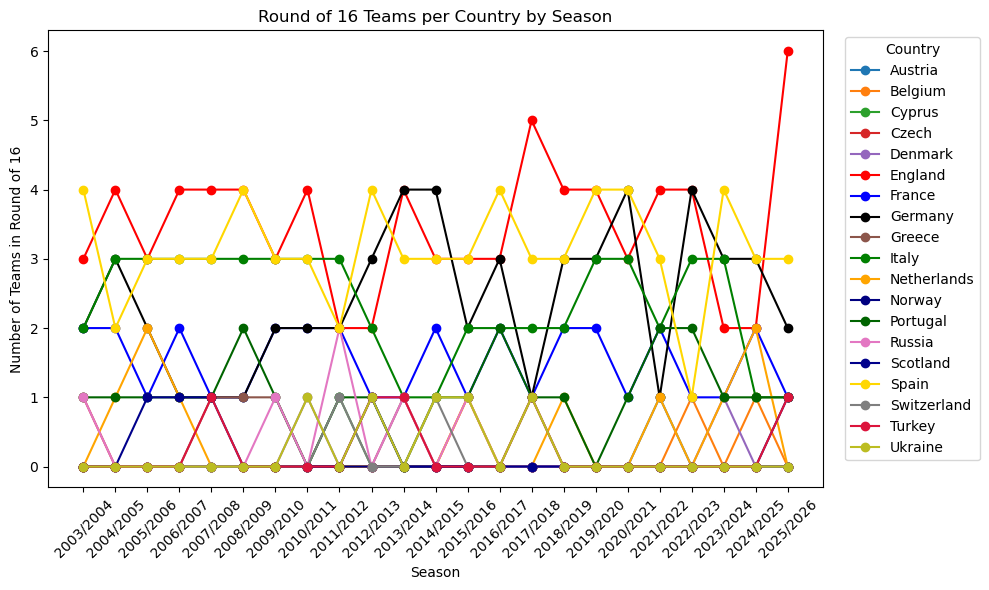

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only Round of 16
round16 = dataset[dataset["knock_out_stage"] == "round 1 of 16"]

# Group by season and country
grouped = (
    round16
    .groupby(["season_year", "country_name"])
    .size()
    .reset_index(name="num_teams_round16")
)

# Create pivot table
pivot_df = grouped.pivot(
    index="season_year",
    columns="country_name",
    values="num_teams_round16"
).fillna(0)

# Sort seasons chronologically
pivot_df = pivot_df.sort_index()

# Country colour mapping (dominant flag colour)
country_colors = {
    "Germany": "black",
    "England": "red",
    "Spain": "gold",
    "France": "blue",
    "Italy": "green",
    "Portugal": "darkgreen",
    "Netherlands": "orange",
    "Turkey": "crimson",
    "Norway": "navy",
    "Scotland": "darkblue"
}

plt.figure(figsize=(10, 6))

for country in pivot_df.columns:
    color = country_colors.get(country, None)  # default if not mapped
    plt.plot(
        pivot_df.index,
        pivot_df[country],
        marker="o",
        label=country,
        color=color
    )

plt.xlabel("Season")
plt.ylabel("Number of Teams in Round of 16")
plt.title("Round of 16 Teams per Country by Season")
plt.xticks(rotation=45)

# Legend outside (top-right)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Country"
)

plt.tight_layout()
plt.show()

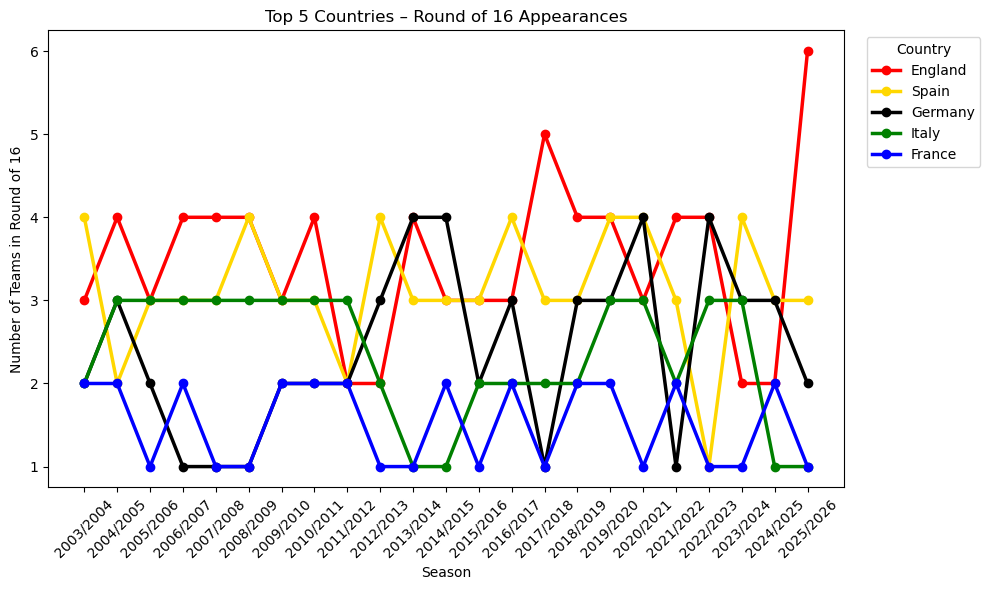

In [20]:
# Calculate total appearances
totals = pivot_df.sum().sort_values(ascending=False)

# Select top 5 countries
top_countries = totals.head(5).index

plt.figure(figsize=(10,6))

for country in top_countries:
    plt.plot(
        pivot_df.index,
        pivot_df[country],
        marker="o",
        linewidth=2.5,
        label=country,
        color=country_colors.get(country, None)
    )

plt.xlabel("Season")
plt.ylabel("Number of Teams in Round of 16")
plt.title("Top 5 Countries – Round of 16 Appearances")
plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Country"
)

plt.tight_layout()
plt.show()

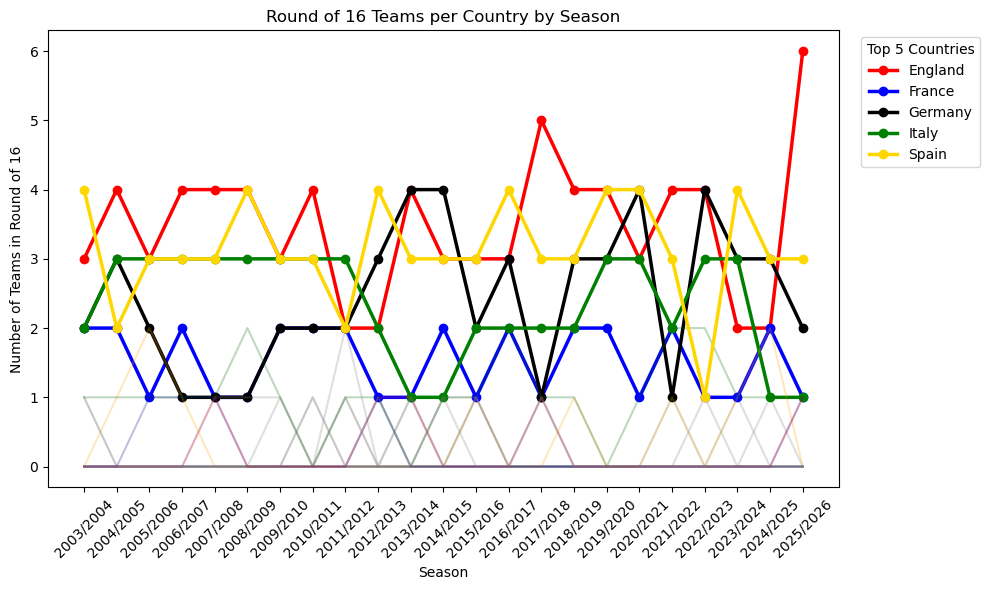

In [21]:
# Identify top 5
top_countries = pivot_df.sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10,6))

for country in pivot_df.columns:
    if country in top_countries:
        plt.plot(
            pivot_df.index,
            pivot_df[country],
            marker="o",
            linewidth=2.5,
            label=country,
            color=country_colors.get(country, None)
        )
    else:
        plt.plot(
            pivot_df.index,
            pivot_df[country],
            color=country_colors.get(country, "grey"),
            alpha=0.25
        )

plt.xlabel("Season")
plt.ylabel("Number of Teams in Round of 16")
plt.title("Round of 16 Teams per Country by Season")
plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Top 5 Countries"
)

plt.tight_layout()
plt.show()

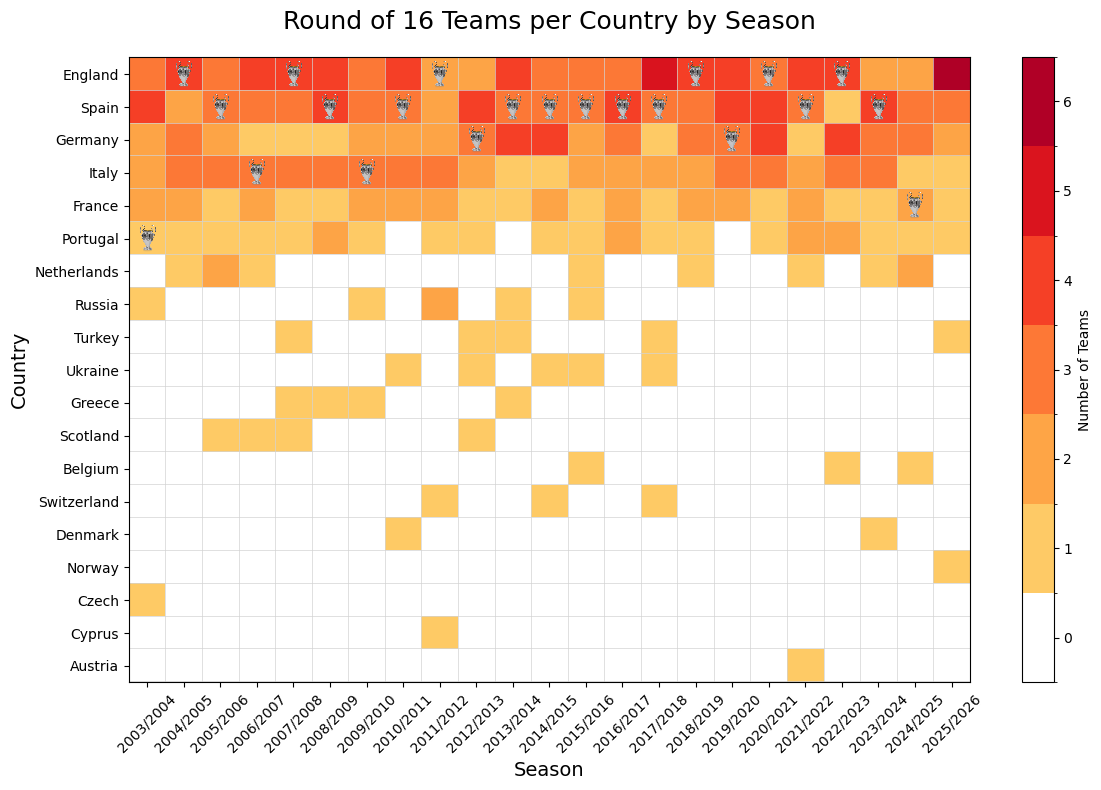

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# -------------------------------
# Prepare heatmap data
# -------------------------------
# Rank countries by total appearances
ranked_countries = pivot_df.sum().sort_values(ascending=False).index
heatmap_df = pivot_df[ranked_countries].T

# Get champions per season
champions = dataset[dataset["knock_out_stage_status"] == "winner"]
champions = champions[["season_year", "country_name"]].drop_duplicates()

# Max number of teams for colormap
vmax = int(heatmap_df.max().max())

# -------------------------------
# Create discrete colormap
# -------------------------------
colors = ["white"] + list(plt.cm.YlOrRd(np.linspace(0.3, 0.9, vmax)))
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, vmax + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------
# Plot heatmap
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_df, aspect="auto", cmap=cmap, norm=norm)

# -------------------------------
# Axis formatting
# -------------------------------
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)

# Grey grid lines, slightly nudged for alignment
y_lines = np.arange(-0.5, heatmap_df.shape[0], 1) - 0.03
x_lines = np.arange(-0.5, heatmap_df.shape[1], 1)
ax.set_yticks(y_lines, minor=True)
ax.set_xticks(x_lines, minor=True)
ax.grid(which="minor", color="lightgrey", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# -------------------------------
# Overlay trophy for champions
# -------------------------------
image_path = os.path.join("Images and others", "Champions League Trophy.png")
trophy_img = mpimg.imread(image_path)
imagebox = OffsetImage(trophy_img, zoom=0.03)  # adjust zoom as needed

for _, row in champions.iterrows():
    season = row["season_year"]
    country = row["country_name"]

    if season in heatmap_df.columns and country in heatmap_df.index:
        x = list(heatmap_df.columns).index(season)
        y = list(heatmap_df.index).index(country)

        ab = AnnotationBbox(imagebox, (x, y), frameon=False, box_alignment=(0.5, 0.5), zorder=5)
        ax.add_artist(ab)

# -------------------------------
# Colorbar and labels
# -------------------------------
cbar = fig.colorbar(im, ticks=np.arange(0, vmax + 1))
cbar.set_label("Number of Teams")

ax.set_title(
    "Round of 16 Teams per Country by Season",
    fontsize=18,
    pad=20
)

ax.set_xlabel("Season", fontsize=14)
ax.set_ylabel("Country", fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join("Images and others", "round_of_16_heatmap.png"), dpi=600, bbox_inches="tight")

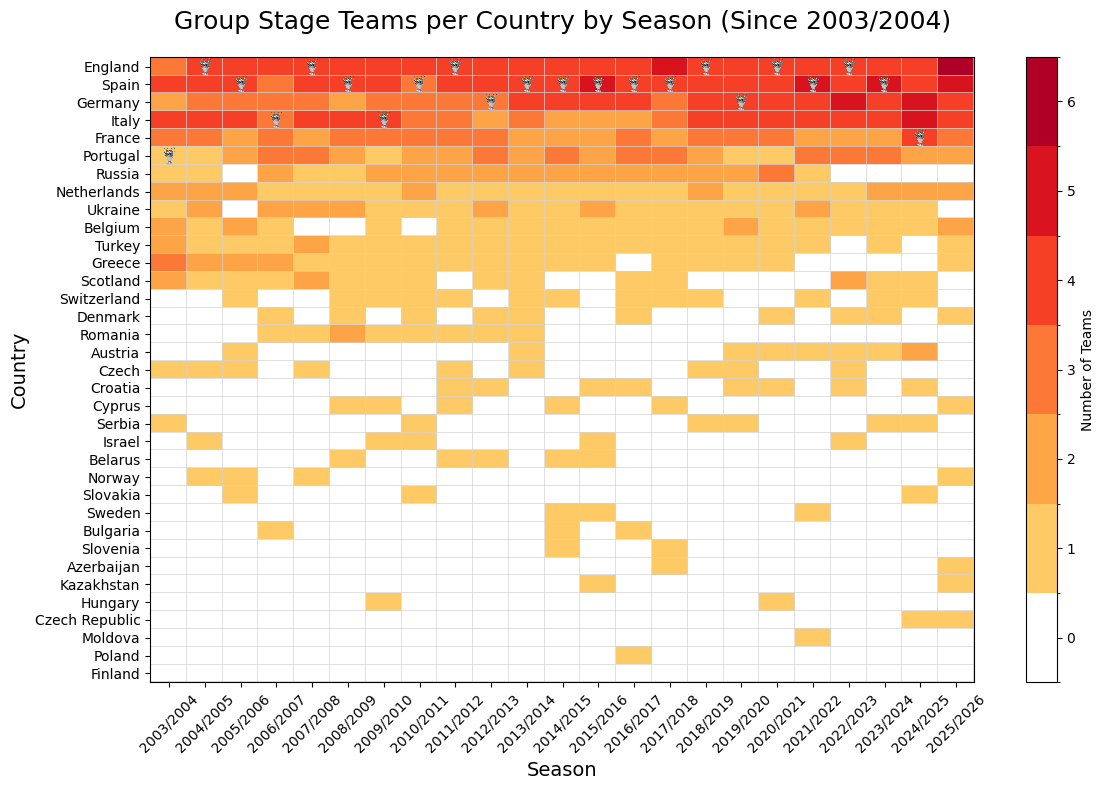

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# -------------------------------
# Filter from 2003/2004 onward
# -------------------------------

pivot_group_filtered = pivot_group_df.sort_index().loc["2003/2004":]

# Rank countries by total group stage appearances (since 2003/2004)
ranked_countries = (
    pivot_group_filtered
    .sum()
    .sort_values(ascending=False)
    .index
)

heatmap_df = pivot_group_filtered[ranked_countries].T

# Filter champions to same seasons
champions = dataset[
    (dataset["knock_out_stage_status"] == "winner") &
    (dataset["season_year"] >= "2003/2004")
][["season_year", "country_name"]].drop_duplicates()

# Max number of teams for colormap
vmax = int(heatmap_df.max().max())

# -------------------------------
# Create discrete RED colormap
# -------------------------------

colors = ["white"] + list(plt.cm.YlOrRd(np.linspace(0.3, 0.9, vmax)))
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, vmax + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -------------------------------
# Plot heatmap
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_df, aspect="auto", cmap=cmap, norm=norm)

# -------------------------------
# Axis formatting
# -------------------------------

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)

# Grey grid lines
y_lines = np.arange(-0.5, heatmap_df.shape[0], 1) - 0.05
x_lines = np.arange(-0.5, heatmap_df.shape[1], 1) - 0.03
ax.set_yticks(y_lines, minor=True)
ax.set_xticks(x_lines, minor=True)
ax.grid(which="minor", color="lightgrey", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# -------------------------------
# Overlay trophy for champions
# -------------------------------

image_path = os.path.join("Images and others", "Champions League Trophy.png")
trophy_img = mpimg.imread(image_path)
imagebox = OffsetImage(trophy_img, zoom=0.02)

for _, row in champions.iterrows():
    season = row["season_year"]
    country = row["country_name"]

    if season in heatmap_df.columns and country in heatmap_df.index:
        x = list(heatmap_df.columns).index(season)
        y = list(heatmap_df.index).index(country)

        ab = AnnotationBbox(
            imagebox,
            (x, y),
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=5
        )
        ax.add_artist(ab)

# -------------------------------
# Colorbar and labels
# -------------------------------

cbar = fig.colorbar(im, ticks=np.arange(0, vmax + 1))
cbar.set_label("Number of Teams")

ax.set_title(
    "Group Stage Teams per Country by Season (Since 2003/2004)",
    fontsize=18,
    pad=20
)

ax.set_xlabel("Season", fontsize=14)
ax.set_ylabel("Country", fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig(
    os.path.join("Images and others", "group_stage_heatmap_since_2003_red.png"),
    dpi=600,
    bbox_inches="tight"
)

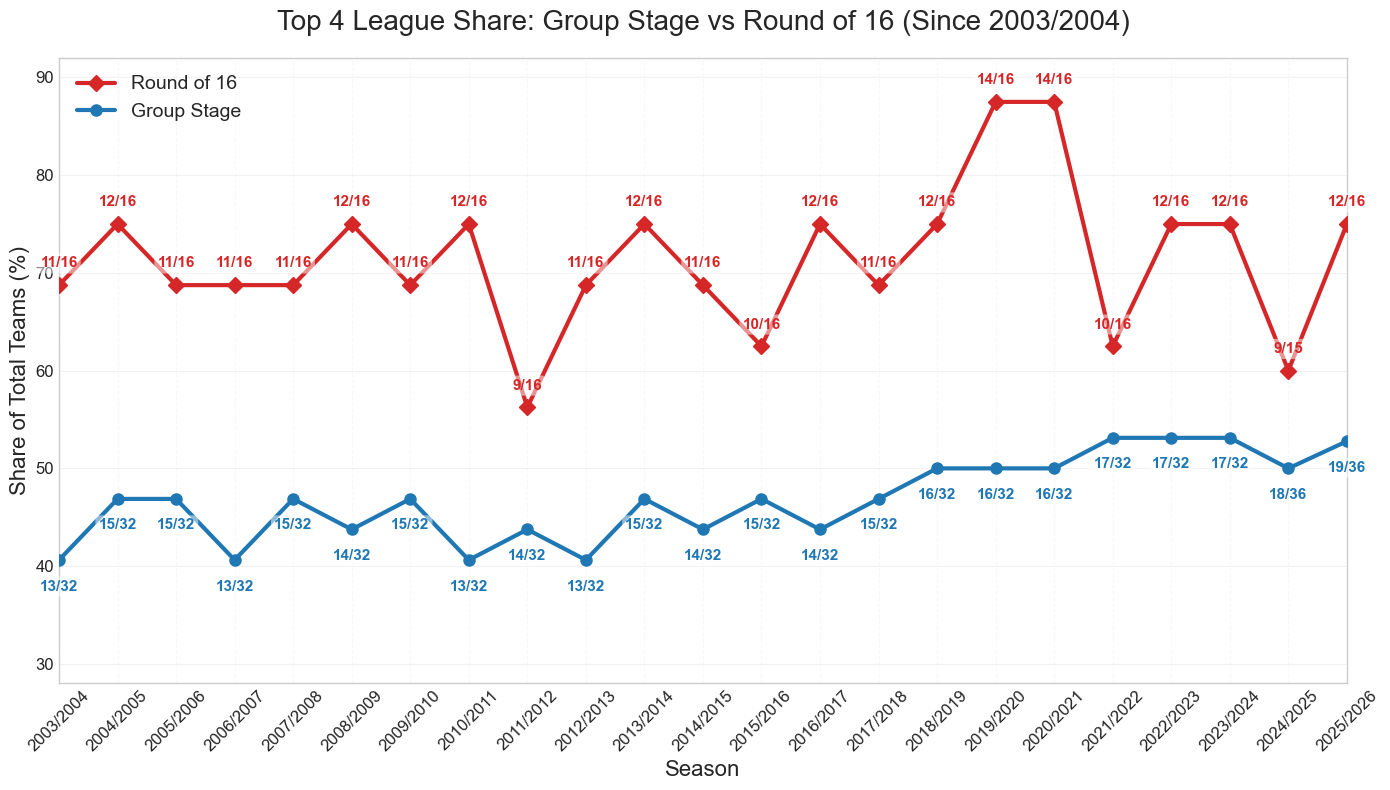

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Filter + Align
# -------------------------------

group = pivot_group_df.sort_index().loc["2003/2004":]
ro16 = pivot_df.sort_index().loc["2003/2004":]

group, ro16 = group.align(ro16, join="outer", fill_value=0)

top4 = ["England", "Spain", "Germany", "Italy"]

# -------------------------------
# 2. Compute shares + fractions
# -------------------------------

group_top4 = group[top4].sum(axis=1)
group_total = group.sum(axis=1)

ro16_top4 = ro16[top4].sum(axis=1)
ro16_total = ro16.sum(axis=1)

group_share = group_top4 / group_total * 100
ro16_share = ro16_top4 / ro16_total * 100

# -------------------------------
# 3. Plot
# -------------------------------

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

color_group = "#1f77b4"
color_ro16 = "#d62728"

# Put grid BEHIND everything
ax.set_axisbelow(True)

# Horizontal gridlines (stronger)
ax.grid(axis="y", alpha=0.25)

# Vertical gridlines (subtle + dashed)
ax.grid(axis="x", alpha=0.12, linestyle="--")

# Plot RO16 FIRST (for legend order)
line_ro16, = ax.plot(
    ro16_share.index,
    ro16_share.values,
    marker="D",
    markersize=8,
    linewidth=3,
    color=color_ro16,
    label="Round of 16",
    zorder=3
)

line_group, = ax.plot(
    group_share.index,
    group_share.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color=color_group,
    label="Group Stage",
    zorder=3
)

# -------------------------------
# 4. Annotate fractions (closer)
# -------------------------------

for i, season in enumerate(group_share.index):

    # Group stage BELOW
    ax.text(
        season,
        group_share.iloc[i] - 2,
        f"{int(group_top4.iloc[i])}/{int(group_total.iloc[i])}",
        ha="center",
        va="top",
        fontsize=11,
        fontweight="bold",
        color=color_group,
        zorder=4,
        bbox=dict(
            facecolor="white",
            alpha=0.5,
            edgecolor="none",
            boxstyle="round,pad=0.2"
        )
    )

    # RO16 ABOVE
    ax.text(
        season,
        ro16_share.iloc[i] + 1.5,
        f"{int(ro16_top4.iloc[i])}/{int(ro16_total.iloc[i])}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=color_ro16,
        zorder=4,
        bbox=dict(
            facecolor="white",
            alpha=0.5,
            edgecolor="none",
            boxstyle="round,pad=0.2"
        )
    )

# -------------------------------
# 5. Styling
# -------------------------------

ax.set_ylim(28, 92)

# Bigger axis labels
ax.set_ylabel("Share of Total Teams (%)", fontsize=16)
ax.set_xlabel("Season", fontsize=16)

# Slightly larger title for hierarchy balance
ax.set_title(
    "Top 4 League Share: Group Stage vs Round of 16 (Since 2003/2004)",
    fontsize=20,
    pad=20
)

ax.margins(x=0)

# Bigger tick labels
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.xticks(rotation=45)

ax.legend(
    handles=[line_ro16, line_group],
    frameon=False,
    fontsize=14,
    loc="upper left"
)

plt.tight_layout()
plt.show()